# Volve Oil Production Data Science Project

## Notebook 01: Exploratory Production and Well Behaviour Analysis

This notebook explores the temporal and operational behaviour of the Volve production wells after completion of the structural dataset audit.

The analysis focuses on production history, well-to-well differences, oil and gas behaviour, produced water, injection activity, operational downtime, and variables that may later support forecasting or other machine learning tasks.

No machine learning target is selected at this stage. The purpose of this notebook is to understand the behaviour of the data before defining the modelling problem.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path(
    r"F:\DataScience_Projects\Volve_Oil_Production"
)

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Volve production data.xlsx"
)

MONTHLY_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "monthly_production_clean.csv"
)

EDA_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "01_eda"
)

EDA_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Project root:", PROJECT_ROOT)
print("Raw workbook exists:", RAW_DATA_PATH.exists())
print("Clean monthly data exists:", MONTHLY_DATA_PATH.exists())
print("EDA output folder:", EDA_OUTPUT_DIR)

Project root: F:\DataScience_Projects\Volve_Oil_Production
Raw workbook exists: True
Clean monthly data exists: True
EDA output folder: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda


In [2]:
daily_df = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name="Daily Production Data"
)

monthly_df = pd.read_csv(
    MONTHLY_DATA_PATH,
    parse_dates=["MONTH_START"]
)


print("Daily dataset shape:", daily_df.shape)
print("Monthly dataset shape:", monthly_df.shape)

print("\nDaily coverage:")
print(
    daily_df["DATEPRD"].min(),
    "to",
    daily_df["DATEPRD"].max()
)

print("\nMonthly coverage:")
print(
    monthly_df["MONTH_START"].min(),
    "to",
    monthly_df["MONTH_START"].max()
)

Daily dataset shape: (15634, 24)
Monthly dataset shape: (526, 11)

Daily coverage:
2007-09-01 00:00:00 to 2016-12-01 00:00:00

Monthly coverage:
2007-09-01 00:00:00 to 2016-12-01 00:00:00


## 1. Analysis Dataset Preparation

The audited daily dataset is separated according to operational role. Production and injection records are analysed independently because their measurements and physical meanings differ.

Additional temporal and activity variables are created only in the working DataFrames. The raw source workbook remains unchanged.

In [3]:
daily_analysis = daily_df.copy()

daily_analysis["DATEPRD"] = pd.to_datetime(
    daily_analysis["DATEPRD"]
)

daily_analysis["YEAR"] = (
    daily_analysis["DATEPRD"].dt.year
)

daily_analysis["MONTH"] = (
    daily_analysis["DATEPRD"].dt.month
)

daily_analysis["YEAR_MONTH"] = (
    daily_analysis["DATEPRD"]
    .dt.to_period("M")
)


daily_analysis["ACTIVITY_STATE"] = np.select(
    [
        daily_analysis["ON_STREAM_HRS"] > 0,
        daily_analysis["ON_STREAM_HRS"] == 0
    ],
    [
        "active",
        "inactive"
    ],
    default="unknown"
)


production_df = (
    daily_analysis[
        daily_analysis["FLOW_KIND"]
        == "production"
    ]
    .copy()
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATEPRD"
        ]
    )
)


injection_df = (
    daily_analysis[
        daily_analysis["FLOW_KIND"]
        == "injection"
    ]
    .copy()
    .sort_values(
        [
            "NPD_WELL_BORE_NAME",
            "DATEPRD"
        ]
    )
)


print(
    "Production records:",
    len(production_df)
)

print(
    "Injection records:",
    len(injection_df)
)

print(
    "Producer wells:",
    production_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

print(
    "Injector wells:",
    injection_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

Production records: 9161
Injection records: 6473
Producer wells: 6
Injector wells: 2


## 2. Field-Level Production History

The first exploratory view examines the combined monthly production behaviour of all producing wellbores.

Monthly aggregation reduces day-to-day operational noise and provides a clearer view of the overall production history of the field.

In [4]:
field_monthly = (
    production_df
    .groupby(
        "YEAR_MONTH",
        as_index=False
    )
    .agg(
        oil_volume=(
            "BORE_OIL_VOL",
            "sum"
        ),

        gas_volume=(
            "BORE_GAS_VOL",
            "sum"
        ),

        water_volume=(
            "BORE_WAT_VOL",
            "sum"
        ),

        on_stream_hours=(
            "ON_STREAM_HRS",
            "sum"
        ),

        producing_wells=(
            "NPD_WELL_BORE_NAME",
            "nunique"
        )
    )
)


field_monthly["DATE"] = (
    field_monthly["YEAR_MONTH"]
    .dt.to_timestamp()
)


print(
    "Monthly field observations:",
    len(field_monthly)
)

print(
    "First month:",
    field_monthly["DATE"].min()
)

print(
    "Last month:",
    field_monthly["DATE"].max()
)

display(field_monthly.head())

Monthly field observations: 104
First month: 2008-02-01 00:00:00
Last month: 2016-09-01 00:00:00


,YEAR_MONTH,oil_volume,gas_volume,water_volume,on_stream_hours,producing_wells,DATE
0,2008-02,49091.06,7068009.29,412.61,406.62499,2,2008-02-01
1,2008-03,83361.26,12191170.91,27.42,655.10834,2,2008-03-01
2,2008-04,74532.45,11506440.74,482.05,613.64666,2,2008-04-01
3,2008-05,125478.56,19091871.52,16280.12,716.19167,2,2008-05-01
4,2008-06,143786.85,21512333.93,474.37,675.91669,2,2008-06-01


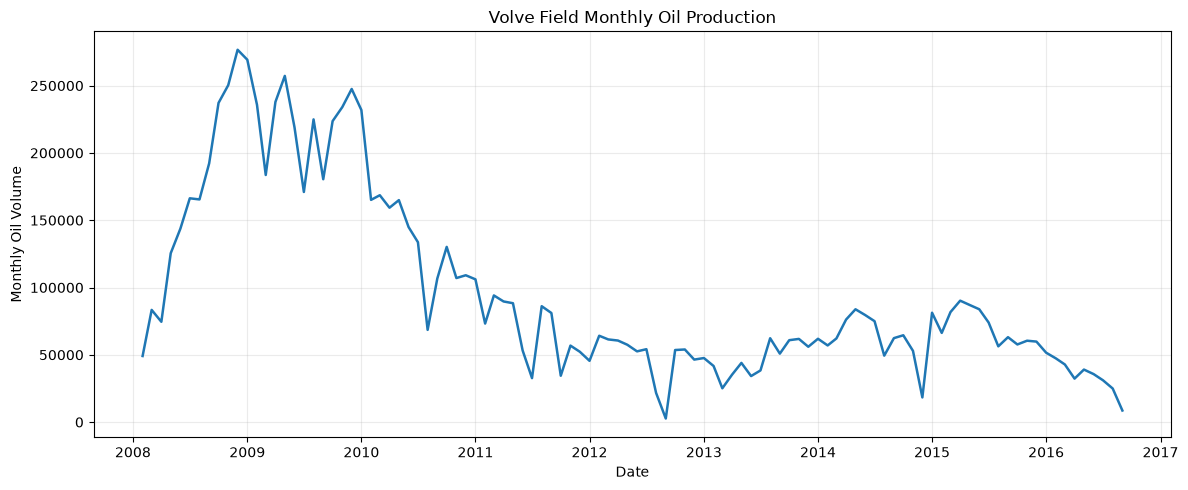

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\01_field_monthly_oil_production.png


In [5]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.plot(
    field_monthly["DATE"],
    field_monthly["oil_volume"],
    linewidth=1.8
)

ax.set_title(
    "Volve Field Monthly Oil Production"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Monthly Oil Volume"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

figure_path = (
    EDA_OUTPUT_DIR
    / "01_field_monthly_oil_production.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

### 2.1 Field Production Peak and Producer Participation

The field-level production curve may reflect both changes in individual well performance and changes in the number of producing wells.

The peak production period and the number of producer wells contributing to each month are therefore examined before interpreting the field-wide decline.

In [6]:
peak_index = (
    field_monthly["oil_volume"]
    .idxmax()
)

peak_record = (
    field_monthly.loc[
        peak_index
    ]
)


print("FIELD OIL PRODUCTION PEAK")
print("-" * 60)

print(
    "Peak month:",
    peak_record["DATE"]
)

print(
    "Peak monthly oil volume:",
    round(
        peak_record["oil_volume"],
        2
    )
)

print(
    "Producing wells during peak:",
    int(
        peak_record["producing_wells"]
    )
)


print("\nLowest monthly oil volume:")

minimum_record = (
    field_monthly.loc[
        field_monthly[
            "oil_volume"
        ].idxmin()
    ]
)

print(
    "Month:",
    minimum_record["DATE"]
)

print(
    "Oil volume:",
    round(
        minimum_record["oil_volume"],
        2
    )
)

print(
    "Producing wells:",
    int(
        minimum_record["producing_wells"]
    )
)

FIELD OIL PRODUCTION PEAK
------------------------------------------------------------
Peak month: 2008-12-01 00:00:00
Peak monthly oil volume: 276638.95
Producing wells during peak: 2

Lowest monthly oil volume:
Month: 2012-09-01 00:00:00
Oil volume: 2669.01
Producing wells: 2


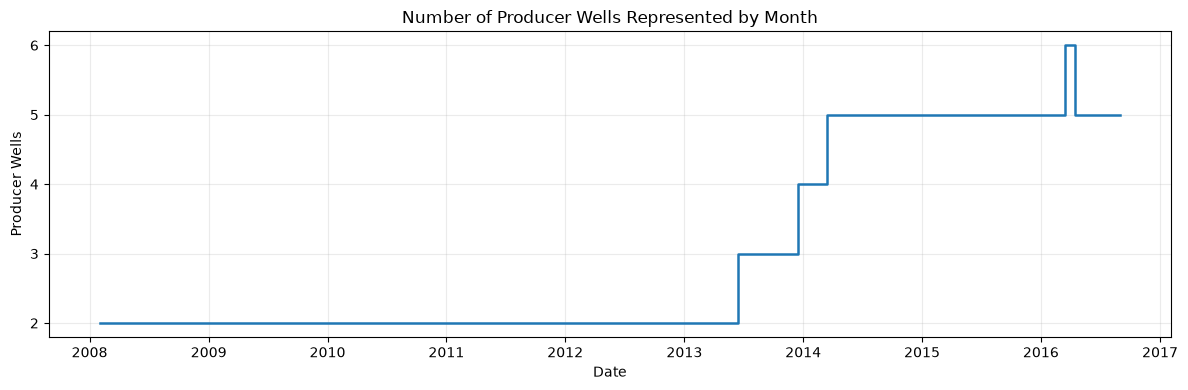

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\02_monthly_producer_well_count.png


In [7]:
fig, ax = plt.subplots(
    figsize=(12, 4)
)

ax.step(
    field_monthly["DATE"],
    field_monthly["producing_wells"],
    where="mid",
    linewidth=1.8
)

ax.set_title(
    "Number of Producer Wells Represented by Month"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Producer Wells"
)

ax.set_yticks(
    sorted(
        field_monthly[
            "producing_wells"
        ].unique()
    )
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

figure_path = (
    EDA_OUTPUT_DIR
    / "02_monthly_producer_well_count.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

## 3. Individual Producer Oil Histories

Field-level aggregation can hide substantial differences between wells.

Monthly oil production is therefore examined separately for each producer to identify differences in start dates, production scale, peak behaviour, decline patterns, interruptions, and late-life performance.

In [8]:
well_monthly_oil = (
    production_df
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "YEAR_MONTH"
        ],
        as_index=False
    )
    .agg(
        oil_volume=(
            "BORE_OIL_VOL",
            "sum"
        ),

        on_stream_hours=(
            "ON_STREAM_HRS",
            "sum"
        )
    )
)


well_monthly_oil["DATE"] = (
    well_monthly_oil[
        "YEAR_MONTH"
    ]
    .dt.to_timestamp()
)


print(
    "Producer-month observations:",
    len(well_monthly_oil)
)

print("\nRecords by producer:")

display(
    well_monthly_oil
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .size()
    .rename("monthly_records")
    .reset_index()
)

Producer-month observations: 311

Records by producer:


,NPD_WELL_BORE_NAME,monthly_records
0,15/9-F-1 C,25
1,15/9-F-11,39
2,15/9-F-12,104
3,15/9-F-14,104
4,15/9-F-15 D,33
5,15/9-F-5,6


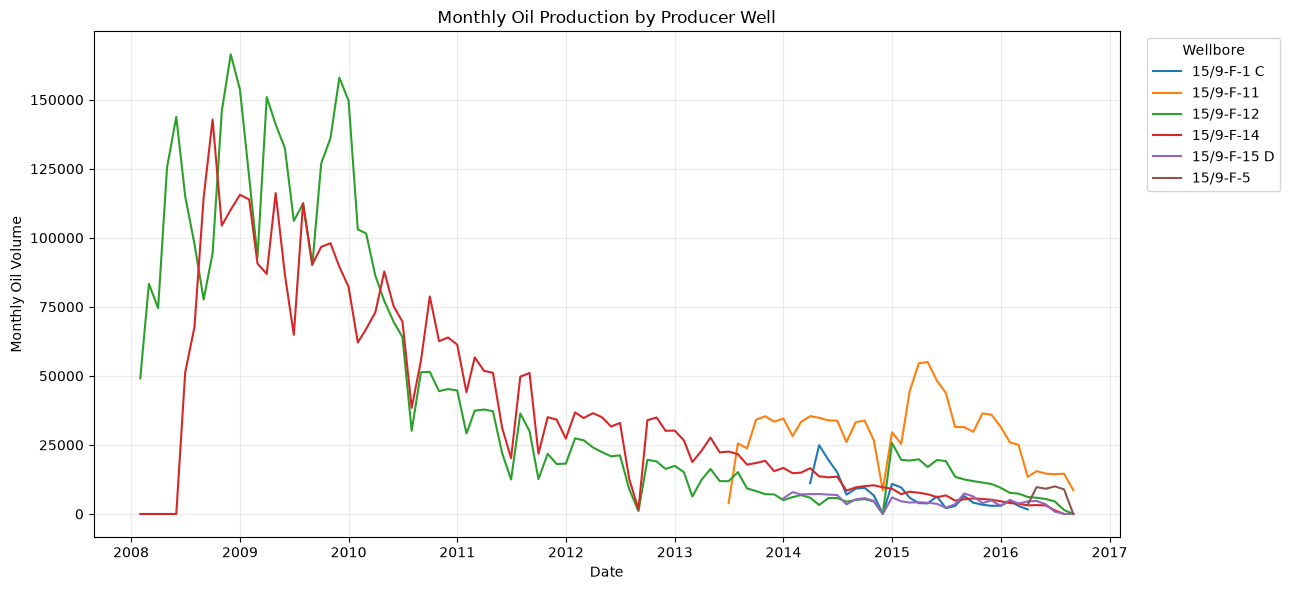

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\03_monthly_oil_by_producer.png


In [9]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

for well_name, group in (
    well_monthly_oil.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    ax.plot(
        group["DATE"],
        group["oil_volume"],
        linewidth=1.5,
        label=well_name
    )


ax.set_title(
    "Monthly Oil Production by Producer Well"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Monthly Oil Volume"
)

ax.legend(
    title="Wellbore",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

figure_path = (
    EDA_OUTPUT_DIR
    / "03_monthly_oil_by_producer.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

### 3.1 Producer Timeline, Peak Production, and Active Participation

The producer histories show substantial differences in start dates, production scale, and duration.

Before interpreting these differences further, each producer is summarised by its first recorded production month, last recorded production month, peak monthly oil production, and peak date.

Producer representation is also distinguished from actual monthly activity because a production-type record may still correspond to zero on-stream hours.

In [10]:
producer_month_summary = (
    well_monthly_oil
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        first_month=(
            "DATE",
            "min"
        ),

        last_month=(
            "DATE",
            "max"
        ),

        monthly_records=(
            "DATE",
            "size"
        ),

        total_oil=(
            "oil_volume",
            "sum"
        ),

        average_monthly_oil=(
            "oil_volume",
            "mean"
        )
    )
    .reset_index()
)


peak_indices = (
    well_monthly_oil
    .groupby(
        "NPD_WELL_BORE_NAME"
    )["oil_volume"]
    .idxmax()
)


producer_peaks = (
    well_monthly_oil
    .loc[
        peak_indices,
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume"
        ]
    ]
    .rename(
        columns={
            "DATE":
                "peak_month",

            "oil_volume":
                "peak_monthly_oil"
        }
    )
)


producer_month_summary = (
    producer_month_summary
    .merge(
        producer_peaks,
        on="NPD_WELL_BORE_NAME",
        how="left"
    )
    .sort_values(
        "first_month"
    )
    .reset_index(drop=True)
)


display(producer_month_summary)

,NPD_WELL_BORE_NAME,first_month,last_month,monthly_records,total_oil,average_monthly_oil,peak_month,peak_monthly_oil
0,15/9-F-12,2008-02-01,2016-09-01,104,4579609.55,44034.707212,2008-12-01,166439.67
1,15/9-F-14,2008-02-01,2016-09-01,104,3942233.39,37906.090288,2008-10-01,142817.06
2,15/9-F-11,2013-07-01,2016-09-01,39,1147849.10,29432.028205,2015-05-01,55029.22
3,15/9-F-15 D,2014-01-01,2016-09-01,33,148518.56,4500.562424,2014-02-01,7898.60
4,15/9-F-1 C,2014-04-01,2016-04-01,25,177709.33,7108.373200,2014-05-01,24901.95
5,15/9-F-5,2016-04-01,2016-09-01,6,41160.68,6860.113333,2016-07-01,9985.29


In [11]:
active_producer_monthly = (
    production_df[
        production_df["ON_STREAM_HRS"] > 0
    ]
    .groupby(
        "YEAR_MONTH"
    )["NPD_WELL_BORE_NAME"]
    .nunique()
    .rename(
        "active_producer_wells"
    )
    .reset_index()
)


field_monthly_activity = (
    field_monthly
    .merge(
        active_producer_monthly,
        on="YEAR_MONTH",
        how="left"
    )
)


field_monthly_activity[
    "active_producer_wells"
] = (
    field_monthly_activity[
        "active_producer_wells"
    ]
    .fillna(0)
    .astype(int)
)


field_monthly_activity[
    "inactive_or_shutdown_wells"
] = (
    field_monthly_activity[
        "producing_wells"
    ]
    -
    field_monthly_activity[
        "active_producer_wells"
    ]
)


print(
    "Months where represented producer count "
    "differs from active producer count:"
)

activity_difference = (
    field_monthly_activity[
        field_monthly_activity[
            "producing_wells"
        ]
        !=
        field_monthly_activity[
            "active_producer_wells"
        ]
    ]
)

print(
    len(activity_difference)
)

display(
    activity_difference[
        [
            "DATE",
            "oil_volume",
            "producing_wells",
            "active_producer_wells",
            "inactive_or_shutdown_wells"
        ]
    ]
)

Months where represented producer count differs from active producer count:
8


,DATE,oil_volume,producing_wells,active_producer_wells,inactive_or_shutdown_wells
0,2008-02-01,49091.06,2,1,1
1,2008-03-01,83361.26,2,1,1
2,2008-04-01,74532.45,2,1,1
3,2008-05-01,125478.56,2,1,1
4,2008-06-01,143786.85,2,1,1
82,2014-12-01,18333.32,5,3,2
102,2016-08-01,24954.66,5,3,2
103,2016-09-01,8609.18,5,1,4


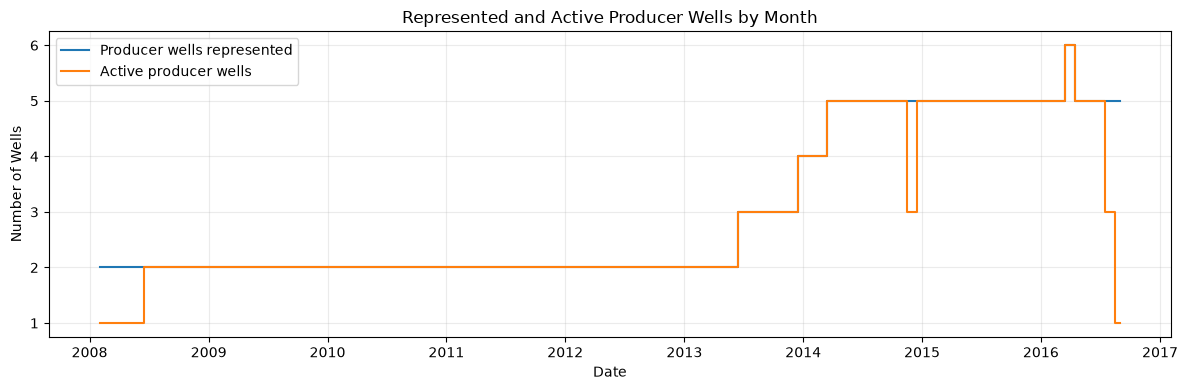

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\04_represented_vs_active_producer_wells.png


In [12]:
fig, ax = plt.subplots(
    figsize=(12, 4)
)

ax.step(
    field_monthly_activity["DATE"],
    field_monthly_activity[
        "producing_wells"
    ],
    where="mid",
    linewidth=1.5,
    label="Producer wells represented"
)

ax.step(
    field_monthly_activity["DATE"],
    field_monthly_activity[
        "active_producer_wells"
    ],
    where="mid",
    linewidth=1.5,
    label="Active producer wells"
)

ax.set_title(
    "Represented and Active Producer Wells by Month"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Number of Wells"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    EDA_OUTPUT_DIR
    / "04_represented_vs_active_producer_wells.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

## 4. Oil Production and Operational Activity

Field-level oil production can fall because of declining well performance, reduced operating time, temporary shutdowns, or a combination of these effects.

This section examines the relationship between oil production and on-stream hours before interpreting low-production periods as production decline.

In [13]:
field_activity_relationship = (
    production_df
    .groupby(
        "YEAR_MONTH",
        as_index=False
    )
    .agg(
        oil_volume=(
            "BORE_OIL_VOL",
            "sum"
        ),

        on_stream_hours=(
            "ON_STREAM_HRS",
            "sum"
        )
    )
)


field_activity_relationship["DATE"] = (
    field_activity_relationship[
        "YEAR_MONTH"
    ]
    .dt.to_timestamp()
)


print(
    "Field-level monthly observations:",
    len(field_activity_relationship)
)

display(
    field_activity_relationship.head()
)

Field-level monthly observations: 104


,YEAR_MONTH,oil_volume,on_stream_hours,DATE
0,2008-02,49091.06,406.62499,2008-02-01
1,2008-03,83361.26,655.10834,2008-03-01
2,2008-04,74532.45,613.64666,2008-04-01
3,2008-05,125478.56,716.19167,2008-05-01
4,2008-06,143786.85,675.91669,2008-06-01


In [14]:
field_oil_onstream_correlation = (
    field_activity_relationship[
        [
            "oil_volume",
            "on_stream_hours"
        ]
    ]
    .corr()
    .loc[
        "oil_volume",
        "on_stream_hours"
    ]
)


print(
    "Correlation between monthly oil volume "
    "and total on-stream hours:"
)

print(
    round(
        field_oil_onstream_correlation,
        4
    )
)

Correlation between monthly oil volume and total on-stream hours:
-0.207


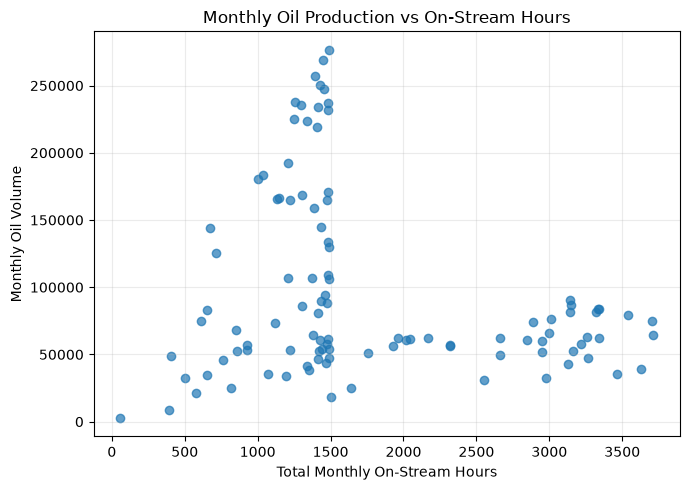

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\05_oil_vs_on_stream_hours.png


In [15]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.scatter(
    field_activity_relationship[
        "on_stream_hours"
    ],
    field_activity_relationship[
        "oil_volume"
    ],
    alpha=0.7
)

ax.set_title(
    "Monthly Oil Production vs On-Stream Hours"
)

ax.set_xlabel(
    "Total Monthly On-Stream Hours"
)

ax.set_ylabel(
    "Monthly Oil Volume"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    EDA_OUTPUT_DIR
    / "05_oil_vs_on_stream_hours.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

In [16]:
field_activity_relationship[
    "oil_per_on_stream_hour"
] = np.where(
    field_activity_relationship[
        "on_stream_hours"
    ] > 0,

    field_activity_relationship[
        "oil_volume"
    ]
    /
    field_activity_relationship[
        "on_stream_hours"
    ],

    np.nan
)


lowest_oil_rate_months = (
    field_activity_relationship
    .dropna(
        subset=[
            "oil_per_on_stream_hour"
        ]
    )
    .nsmallest(
        10,
        "oil_per_on_stream_hour"
    )
)


print(
    "10 months with the lowest "
    "oil volume per on-stream hour:"
)

display(
    lowest_oil_rate_months[
        [
            "DATE",
            "oil_volume",
            "on_stream_hours",
            "oil_per_on_stream_hour"
        ]
    ]
)

10 months with the lowest oil volume per on-stream hour:


,DATE,oil_volume,on_stream_hours,oil_per_on_stream_hour
100,2016-06-01,35659.34,3461.09166,10.302917
99,2016-05-01,39030.25,3631.66667,10.747201
98,2016-04-01,32310.04,2976.92498,10.853495
101,2016-07-01,31059.42,2551.96862,12.170769
82,2014-12-01,18333.32,1502.19154,12.204382
97,2016-03-01,42802.44,3131.08331,13.670170
96,2016-02-01,47367.82,3265.98331,14.503387
102,2016-08-01,24954.66,1637.98334,15.234990
81,2014-11-01,52919.61,3158.98348,16.752101
80,2014-10-01,64514.58,3713.33333,17.373765


### 4.1 Well-Level Oil Productivity

The field-level relationship between oil volume and on-stream hours combines wells with different production histories and production scales.

Oil volume per on-stream hour is therefore calculated separately for each producer and month. This provides a simple measure of production intensity during operating periods and helps distinguish reduced operating time from declining well productivity.

In [17]:
well_monthly_activity = (
    production_df
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "YEAR_MONTH"
        ],
        as_index=False
    )
    .agg(
        oil_volume=(
            "BORE_OIL_VOL",
            "sum"
        ),

        on_stream_hours=(
            "ON_STREAM_HRS",
            "sum"
        )
    )
)


well_monthly_activity["DATE"] = (
    well_monthly_activity[
        "YEAR_MONTH"
    ]
    .dt.to_timestamp()
)


well_monthly_activity[
    "oil_per_on_stream_hour"
] = np.where(
    well_monthly_activity[
        "on_stream_hours"
    ] > 0,

    well_monthly_activity[
        "oil_volume"
    ]
    /
    well_monthly_activity[
        "on_stream_hours"
    ],

    np.nan
)


display(
    well_monthly_activity.head()
)

,NPD_WELL_BORE_NAME,YEAR_MONTH,oil_volume,on_stream_hours,DATE,oil_per_on_stream_hour
0,15/9-F-1 C,2014-04,11142.47,227.50000,2014-04-01,48.977890
1,15/9-F-1 C,2014-05,24901.95,733.83334,2014-05-01,33.934067
2,15/9-F-1 C,2014-06,19617.76,705.91666,2014-06-01,27.790476
3,15/9-F-1 C,2014-07,15085.68,742.41666,2014-07-01,20.319695
4,15/9-F-1 C,2014-08,6970.43,432.99166,2014-08-01,16.098301


In [18]:
well_correlation_rows = []


for well_name, group in (
    well_monthly_activity.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    valid_group = (
        group[
            (
                group["on_stream_hours"] > 0
            )
            &
            group["oil_volume"].notna()
        ]
        .copy()
    )

    if (
        len(valid_group) >= 3
        and
        valid_group[
            "on_stream_hours"
        ].nunique() > 1
        and
        valid_group[
            "oil_volume"
        ].nunique() > 1
    ):

        correlation = (
            valid_group[
                [
                    "oil_volume",
                    "on_stream_hours"
                ]
            ]
            .corr()
            .loc[
                "oil_volume",
                "on_stream_hours"
            ]
        )

    else:
        correlation = np.nan


    well_correlation_rows.append({
        "well":
            well_name,

        "active_months":
            len(valid_group),

        "oil_onstream_correlation":
            correlation,

        "average_oil_per_on_stream_hour":
            valid_group[
                "oil_per_on_stream_hour"
            ].mean()
    })


well_activity_summary = pd.DataFrame(
    well_correlation_rows
)


well_activity_summary[
    "oil_onstream_correlation"
] = (
    well_activity_summary[
        "oil_onstream_correlation"
    ]
    .round(4)
)


well_activity_summary[
    "average_oil_per_on_stream_hour"
] = (
    well_activity_summary[
        "average_oil_per_on_stream_hour"
    ]
    .round(2)
)


display(well_activity_summary)

,well,active_months,oil_onstream_correlation,average_oil_per_on_stream_hour
0,15/9-F-1 C,25,0.7682,16.90
1,15/9-F-11,39,0.4947,43.71
2,15/9-F-12,102,0.2495,68.51
3,15/9-F-14,97,0.1098,64.18
4,15/9-F-15 D,30,0.6497,8.47
5,15/9-F-5,5,0.9733,13.88


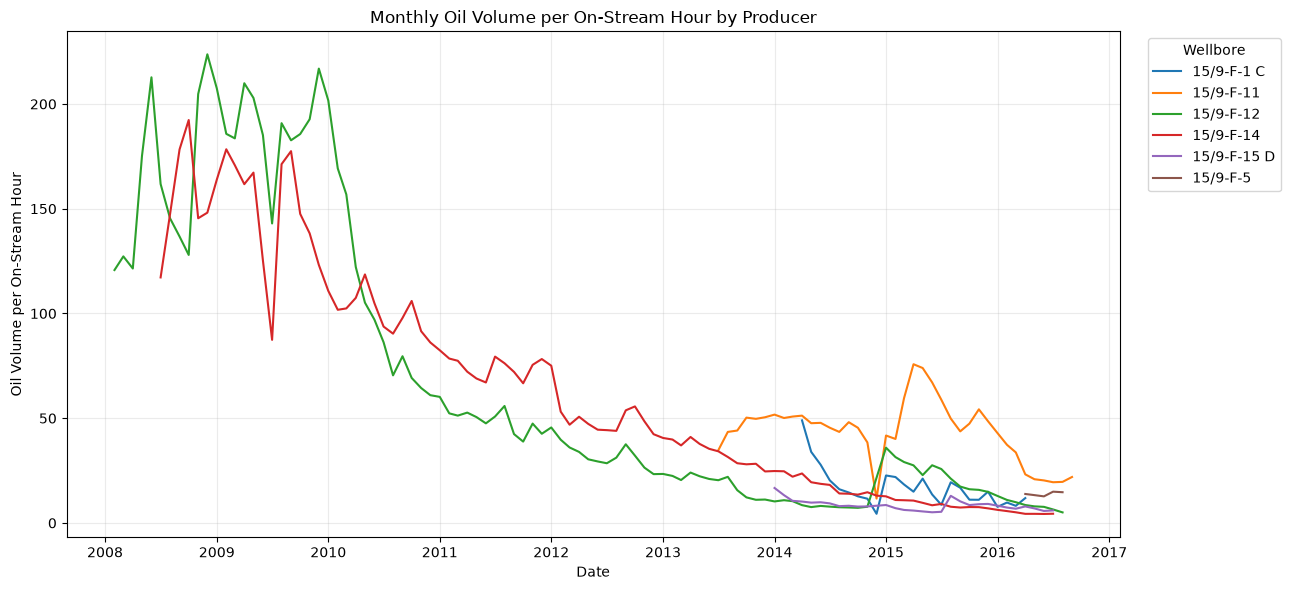

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\06_oil_productivity_by_producer.png


In [19]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)


for well_name, group in (
    well_monthly_activity.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    valid_group = group[
        group[
            "oil_per_on_stream_hour"
        ].notna()
    ]

    ax.plot(
        valid_group["DATE"],
        valid_group[
            "oil_per_on_stream_hour"
        ],
        linewidth=1.5,
        label=well_name
    )


ax.set_title(
    "Monthly Oil Volume per On-Stream Hour by Producer"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Oil Volume per On-Stream Hour"
)

ax.legend(
    title="Wellbore",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    EDA_OUTPUT_DIR
    / "06_oil_productivity_by_producer.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved:",
    figure_path
)

## 5. Produced Water and Water Cut

Produced water is examined together with oil production because increasing water production can indicate changing well and reservoir behaviour during field life.

Water cut is calculated as the proportion of produced liquid represented by water. Only months with positive combined oil and water volume are assigned a water-cut value.

In [20]:
field_liquid_monthly = (
    production_df
    .groupby(
        "YEAR_MONTH",
        as_index=False
    )
    .agg(
        oil_volume=(
            "BORE_OIL_VOL",
            "sum"
        ),

        water_volume=(
            "BORE_WAT_VOL",
            "sum"
        )
    )
)


field_liquid_monthly["DATE"] = (
    field_liquid_monthly[
        "YEAR_MONTH"
    ]
    .dt.to_timestamp()
)


field_liquid_monthly[
    "total_liquid_volume"
] = (
    field_liquid_monthly["oil_volume"]
    +
    field_liquid_monthly["water_volume"]
)


field_liquid_monthly[
    "water_cut_pct"
] = np.where(
    field_liquid_monthly[
        "total_liquid_volume"
    ] > 0,

    (
        field_liquid_monthly[
            "water_volume"
        ]
        /
        field_liquid_monthly[
            "total_liquid_volume"
        ]
    )
    * 100,

    np.nan
)


display(
    field_liquid_monthly.head()
)

,YEAR_MONTH,oil_volume,water_volume,DATE,total_liquid_volume,water_cut_pct
0,2008-02,49091.06,412.61,2008-02-01,49503.67,0.833494
1,2008-03,83361.26,27.42,2008-03-01,83388.68,0.032882
2,2008-04,74532.45,482.05,2008-04-01,75014.50,0.642609
3,2008-05,125478.56,16280.12,2008-05-01,141758.68,11.484390
4,2008-06,143786.85,474.37,2008-06-01,144261.22,0.328827


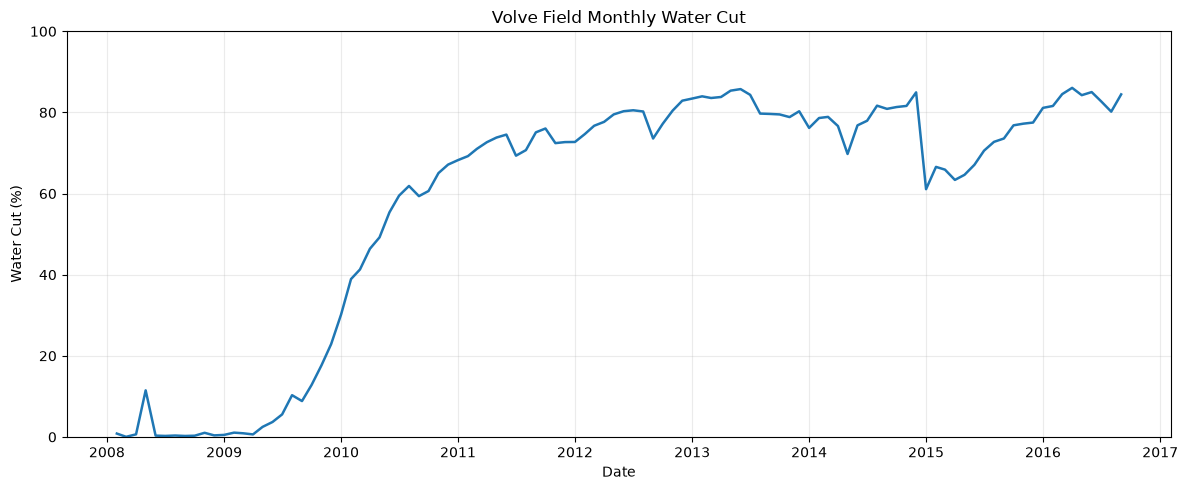

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\07_field_monthly_water_cut.png


In [21]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.plot(
    field_liquid_monthly["DATE"],
    field_liquid_monthly[
        "water_cut_pct"
    ],
    linewidth=1.8
)

ax.set_title(
    "Volve Field Monthly Water Cut"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Water Cut (%)"
)

ax.set_ylim(
    0,
    100
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    EDA_OUTPUT_DIR
    / "07_field_monthly_water_cut.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

In [22]:
well_liquid_monthly = (
    production_df
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "YEAR_MONTH"
        ],
        as_index=False
    )
    .agg(
        oil_volume=(
            "BORE_OIL_VOL",
            "sum"
        ),

        water_volume=(
            "BORE_WAT_VOL",
            "sum"
        )
    )
)


well_liquid_monthly["DATE"] = (
    well_liquid_monthly[
        "YEAR_MONTH"
    ]
    .dt.to_timestamp()
)


well_liquid_monthly[
    "total_liquid_volume"
] = (
    well_liquid_monthly["oil_volume"]
    +
    well_liquid_monthly["water_volume"]
)


well_liquid_monthly[
    "water_cut_pct"
] = np.where(
    well_liquid_monthly[
        "total_liquid_volume"
    ] > 0,

    (
        well_liquid_monthly[
            "water_volume"
        ]
        /
        well_liquid_monthly[
            "total_liquid_volume"
        ]
    )
    * 100,

    np.nan
)

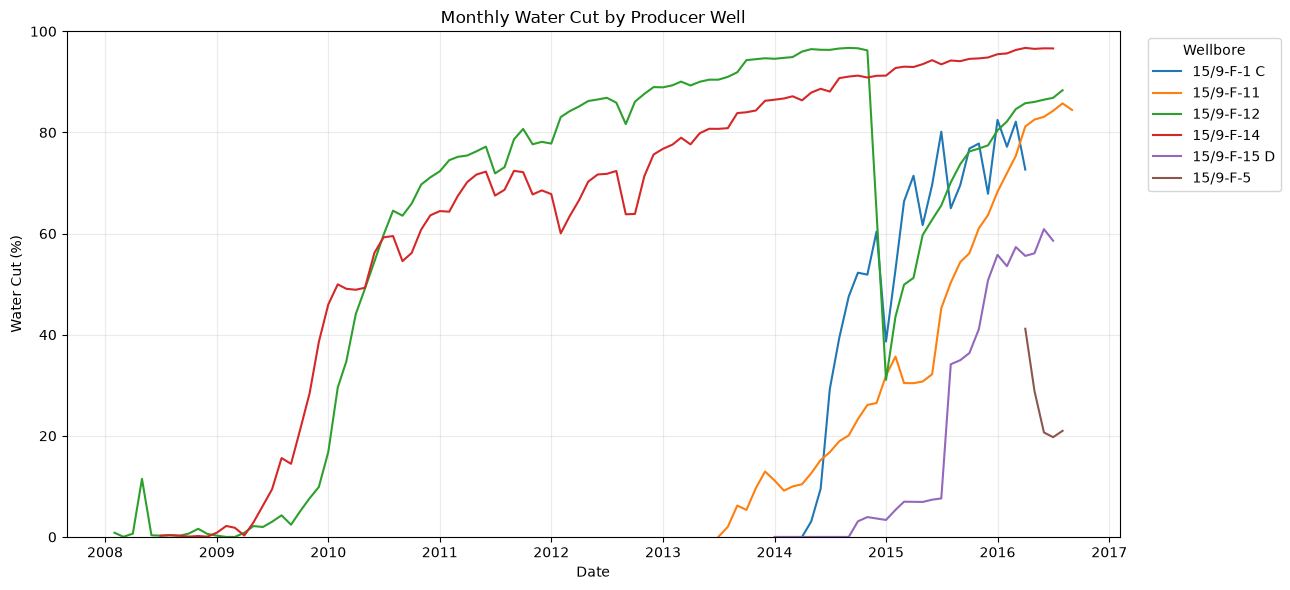

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\08_water_cut_by_producer.png


In [23]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)


for well_name, group in (
    well_liquid_monthly.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    valid_group = group[
        group[
            "water_cut_pct"
        ].notna()
    ]

    ax.plot(
        valid_group["DATE"],
        valid_group[
            "water_cut_pct"
        ],
        linewidth=1.5,
        label=well_name
    )


ax.set_title(
    "Monthly Water Cut by Producer Well"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Water Cut (%)"
)

ax.set_ylim(
    0,
    100
)

ax.legend(
    title="Wellbore",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    EDA_OUTPUT_DIR
    / "08_water_cut_by_producer.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

In [24]:
water_cut_summary = (
    well_liquid_monthly
    .dropna(
        subset=[
            "water_cut_pct"
        ]
    )
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        average_water_cut_pct=(
            "water_cut_pct",
            "mean"
        ),

        maximum_water_cut_pct=(
            "water_cut_pct",
            "max"
        ),

        latest_water_cut_pct=(
            "water_cut_pct",
            "last"
        )
    )
    .round(2)
    .reset_index()
)


display(
    water_cut_summary
)

,NPD_WELL_BORE_NAME,average_water_cut_pct,maximum_water_cut_pct,latest_water_cut_pct
0,15/9-F-1 C,56.23,82.48,72.65
1,15/9-F-11,37.83,85.75,84.46
2,15/9-F-12,60.57,96.72,88.35
3,15/9-F-14,64.72,96.73,96.62
4,15/9-F-15 D,21.56,60.88,58.59
5,15/9-F-5,26.29,41.18,20.99


## 6. Gas Production Behaviour

Gas production is examined relative to oil production because absolute gas volume alone is strongly affected by the scale of oil production.

A monthly gas-to-oil ratio is therefore calculated for producer wells where monthly oil production is positive. The ratio is used here as an exploratory indicator rather than as a reservoir-engineering model.

In [25]:
well_gas_monthly = (
    production_df
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "YEAR_MONTH"
        ],
        as_index=False
    )
    .agg(
        oil_volume=(
            "BORE_OIL_VOL",
            "sum"
        ),

        gas_volume=(
            "BORE_GAS_VOL",
            "sum"
        )
    )
)


well_gas_monthly["DATE"] = (
    well_gas_monthly[
        "YEAR_MONTH"
    ]
    .dt.to_timestamp()
)


well_gas_monthly[
    "gas_oil_ratio"
] = np.where(
    well_gas_monthly[
        "oil_volume"
    ] > 0,

    well_gas_monthly[
        "gas_volume"
    ]
    /
    well_gas_monthly[
        "oil_volume"
    ],

    np.nan
)

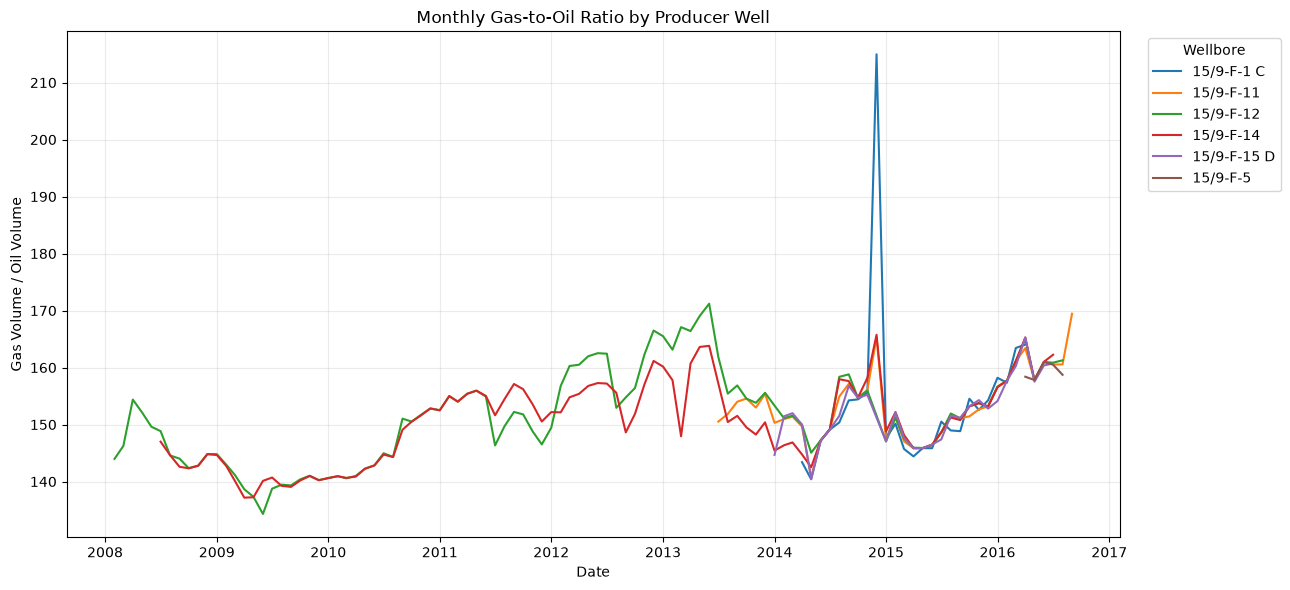

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\09_gas_oil_ratio_by_producer.png


In [26]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)


for well_name, group in (
    well_gas_monthly.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    valid_group = group[
        group[
            "gas_oil_ratio"
        ].notna()
    ]

    ax.plot(
        valid_group["DATE"],
        valid_group[
            "gas_oil_ratio"
        ],
        linewidth=1.5,
        label=well_name
    )


ax.set_title(
    "Monthly Gas-to-Oil Ratio by Producer Well"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Gas Volume / Oil Volume"
)

ax.legend(
    title="Wellbore",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    EDA_OUTPUT_DIR
    / "09_gas_oil_ratio_by_producer.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

In [27]:
gas_oil_summary = (
    well_gas_monthly
    .dropna(
        subset=[
            "gas_oil_ratio"
        ]
    )
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        average_gas_oil_ratio=(
            "gas_oil_ratio",
            "mean"
        ),

        minimum_gas_oil_ratio=(
            "gas_oil_ratio",
            "min"
        ),

        maximum_gas_oil_ratio=(
            "gas_oil_ratio",
            "max"
        )
    )
    .round(2)
    .reset_index()
)


display(
    gas_oil_summary
)

,NPD_WELL_BORE_NAME,average_gas_oil_ratio,minimum_gas_oil_ratio,maximum_gas_oil_ratio
0,15/9-F-1 C,153.68,140.40,214.96
1,15/9-F-11,153.53,140.75,169.45
2,15/9-F-12,151.56,134.32,171.20
3,15/9-F-14,150.48,137.18,165.75
4,15/9-F-15 D,152.15,140.47,165.30
5,15/9-F-5,159.29,157.82,161.00


## 7. Water Injection Behaviour

Injection records are analysed separately from production records.

Monthly water-injection volumes are examined for the injector wells to understand how injection activity changes across field life. No immediate causal relationship between injection and production is assumed because reservoir responses may occur with time delays and depend on well connectivity.

In [28]:
injection_monthly = (
    injection_df
    .groupby(
        [
            "NPD_WELL_BORE_NAME",
            "YEAR_MONTH"
        ],
        as_index=False
    )
    .agg(
        water_injected=(
            "BORE_WI_VOL",
            lambda series:
                series.sum(
                    min_count=1
                )
        ),

        on_stream_hours=(
            "ON_STREAM_HRS",
            lambda series:
                series.sum(
                    min_count=1
                )
        )
    )
)


injection_monthly["DATE"] = (
    injection_monthly[
        "YEAR_MONTH"
    ]
    .dt.to_timestamp()
)


print(
    "Injector-month observations:",
    len(injection_monthly)
)

display(
    injection_monthly.head()
)

Injector-month observations: 217


,NPD_WELL_BORE_NAME,YEAR_MONTH,water_injected,on_stream_hours,DATE
0,15/9-F-4,2007-09,NaN,NaN,2007-09-01
1,15/9-F-4,2007-10,NaN,NaN,2007-10-01
2,15/9-F-4,2007-11,NaN,NaN,2007-11-01
3,15/9-F-4,2007-12,NaN,NaN,2007-12-01
4,15/9-F-4,2008-01,NaN,0.0,2008-01-01


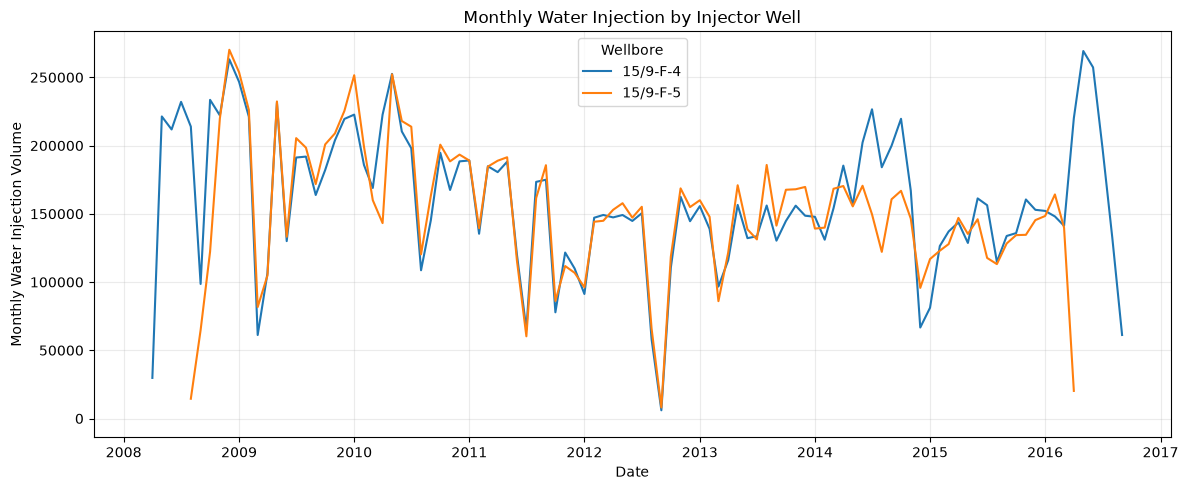

Figure saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda\10_monthly_water_injection_by_well.png


In [29]:
injection_plot_frames = []


for well_name, group in (
    injection_monthly.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    group = (
        group
        .set_index("DATE")
        .sort_index()
    )

    complete_months = pd.date_range(
        start=group.index.min(),
        end=group.index.max(),
        freq="MS"
    )

    group_complete = (
        group
        .reindex(complete_months)
    )

    group_complete[
        "NPD_WELL_BORE_NAME"
    ] = well_name

    group_complete[
        "DATE"
    ] = group_complete.index

    injection_plot_frames.append(
        group_complete.reset_index(
            drop=True
        )
    )


injection_plot_data = pd.concat(
    injection_plot_frames,
    ignore_index=True
)


fig, ax = plt.subplots(
    figsize=(12, 5)
)


for well_name, group in (
    injection_plot_data.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    ax.plot(
        group["DATE"],
        group["water_injected"],
        linewidth=1.5,
        label=well_name
    )


ax.set_title(
    "Monthly Water Injection by Injector Well"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Monthly Water Injection Volume"
)

ax.legend(
    title="Wellbore"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


figure_path = (
    EDA_OUTPUT_DIR
    / "10_monthly_water_injection_by_well.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved:",
    figure_path
)

In [30]:
injection_summary_rows = []


for well_name, group in (
    injection_monthly.groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    group = group.sort_values(
        "DATE"
    )

    active_group = group[
        group["on_stream_hours"] > 0
    ]


    injection_summary_rows.append({
        "NPD_WELL_BORE_NAME":
            well_name,

        "first_recorded_injection_month":
            group["DATE"].min(),

        "last_recorded_injection_month":
            group["DATE"].max(),

        "recorded_injection_months":
            len(group),

        "active_injection_months":
            len(active_group),

        "last_active_injection_month":
            (
                active_group["DATE"].max()
                if len(active_group) > 0
                else pd.NaT
            ),

        "total_water_injected":
            group["water_injected"].sum(
                min_count=1
            ),

        "maximum_monthly_injection":
            group["water_injected"].max()
    })


injection_summary = pd.DataFrame(
    injection_summary_rows
)


display(
    injection_summary
)

,NPD_WELL_BORE_NAME,first_recorded_injection_month,last_recorded_injection_month,recorded_injection_months,active_injection_months,last_active_injection_month,total_water_injected,maximum_monthly_injection
0,15/9-F-4,2007-09-01,2016-12-01,112,102,2016-09-01,1.624073e+07,269279.176161
1,15/9-F-5,2007-09-01,2016-09-01,105,93,2016-04-01,1.408941e+07,270199.399830


## 8. Saving Exploratory Analysis Outputs

Key analytical tables generated during the exploratory analysis are saved alongside the figures so that later notebooks can reuse the results without repeating the analysis.

In [31]:
field_monthly.to_csv(
    EDA_OUTPUT_DIR
    / "01_field_monthly_production.csv",
    index=False
)


producer_month_summary.to_csv(
    EDA_OUTPUT_DIR
    / "02_producer_month_summary.csv",
    index=False
)


well_activity_summary.to_csv(
    EDA_OUTPUT_DIR
    / "03_well_activity_summary.csv",
    index=False
)


field_liquid_monthly.to_csv(
    EDA_OUTPUT_DIR
    / "04_field_liquid_water_cut.csv",
    index=False
)


well_liquid_monthly.to_csv(
    EDA_OUTPUT_DIR
    / "05_well_liquid_water_cut.csv",
    index=False
)


water_cut_summary.to_csv(
    EDA_OUTPUT_DIR
    / "06_water_cut_summary.csv",
    index=False
)


well_gas_monthly.to_csv(
    EDA_OUTPUT_DIR
    / "07_well_gas_oil_ratio.csv",
    index=False
)


gas_oil_summary.to_csv(
    EDA_OUTPUT_DIR
    / "08_gas_oil_summary.csv",
    index=False
)


injection_monthly.to_csv(
    EDA_OUTPUT_DIR
    / "09_injection_monthly.csv",
    index=False
)


injection_summary.to_csv(
    EDA_OUTPUT_DIR
    / "10_injection_summary.csv",
    index=False
)


print(
    "NOTEBOOK 01 ANALYTICAL OUTPUTS SAVED"
)

print(
    "Output directory:",
    EDA_OUTPUT_DIR
)

NOTEBOOK 01 ANALYTICAL OUTPUTS SAVED
Output directory: F:\DataScience_Projects\Volve_Oil_Production\outputs\01_eda


## 9. Exploratory Analysis Conclusions

The exploratory analysis identified substantial differences in production history, operating behaviour, and fluid composition across the Volve wells.

Field oil production reached its highest level during the early producing period and subsequently showed an overall long-term decline with several temporary interruptions and later production contributions from additional wells. The producer-level analysis showed that the field-wide pattern cannot be interpreted as the decline of a single homogeneous production system. Wells entered production at different times, operated at different production scales, and experienced different levels of downtime.

Field-level monthly oil volume showed only a weak relationship with total on-stream hours, with a correlation of -0.207. The well-level results were more varied, with operating time more closely associated with oil production for some producers than for others. Oil volume per on-stream hour also declined substantially for the long-history producers, particularly 15/9-F-12 and 15/9-F-14. These results show that operating time alone does not capture the long-term changes observed in producer-well oil output.

Produced-water behaviour showed a strong change across field life. Field water cut increased substantially from the early production period and remained high during much of the later field history. The long-history producers 15/9-F-12 and 15/9-F-14 reached particularly high late-life water cuts. Water production and water cut are therefore important variables for later decline and forecasting analysis.

The gas-to-oil volume ratio was comparatively stable across most producer wells, although temporary deviations were observed. This behaviour differed from the much stronger long-term change observed in water cut.

Water injection was substantial throughout the field history and involved wells 15/9-F-4 and 15/9-F-5. Injection and production were kept analytically separate, and no direct causal relationship was assumed. The operational-role history of 15/9-F-5 remains especially important because it contains a long injection phase followed by production activity and a final inactive injection-role record.

Overall, the exploratory analysis shows that future modelling should account for well identity, temporal production history, operating time, fluid composition, and differing well life-cycle stages. The results provide evidence for proceeding to a more focused analysis of production decline, temporal features, and candidate forecasting targets rather than selecting a machine learning target from the raw dataset without prior investigation.